Grid shape: (409, 270)
Raw dataset shape: (110430, 469)
Reshaped dataset shape: (409, 270, 469)


/tmp/ipykernel_295319/3992180477.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


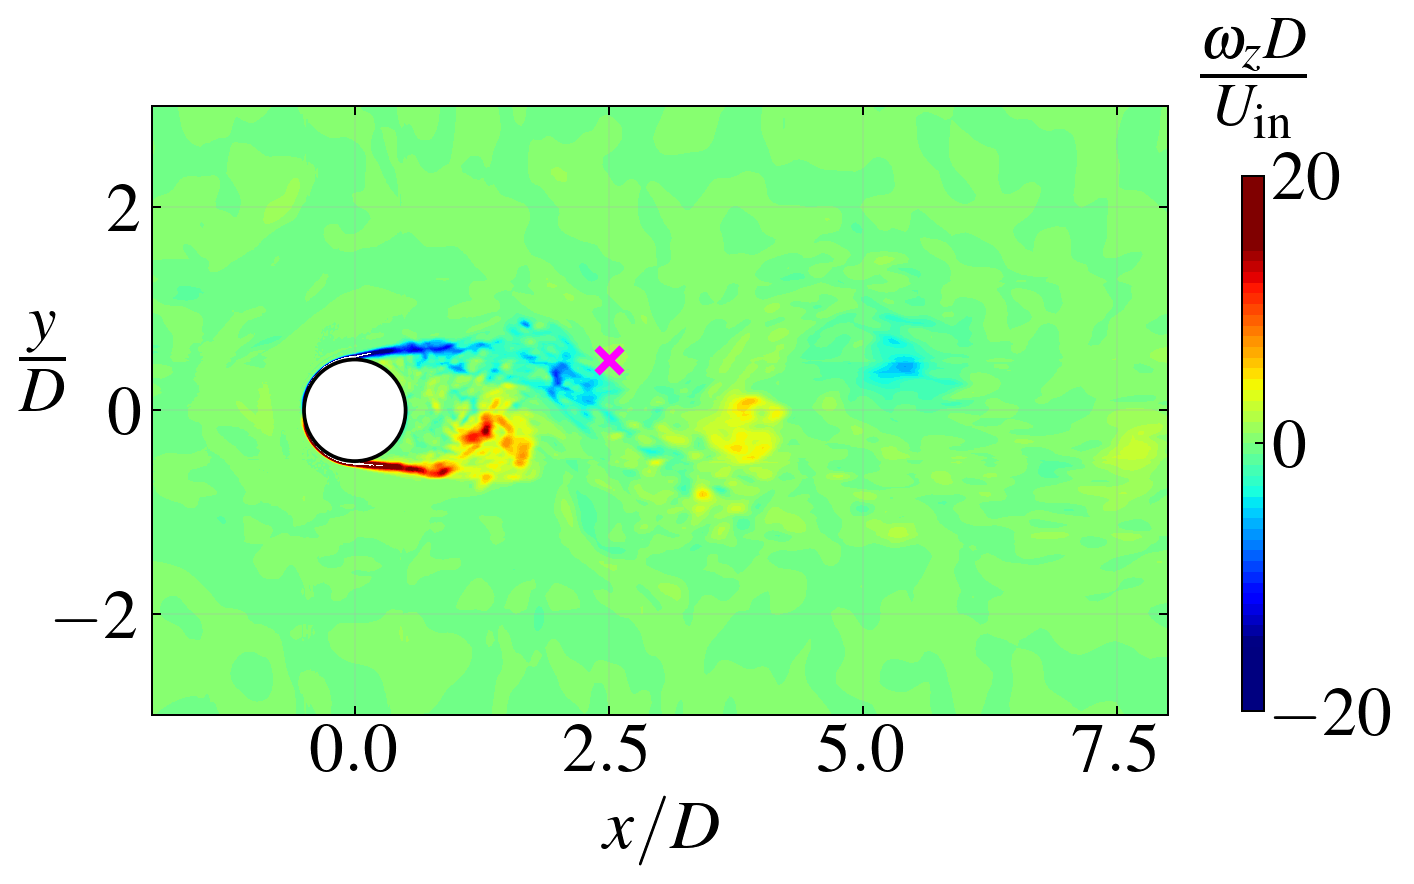

In [35]:

import h5py
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
import matplotlib.pyplot as plt
# TeX-like styling suitable for journal figures
master_font_size = 28
mpl.rcParams.update({
    'figure.figsize': (6.0, 2.8),
    'figure.dpi': 180,
    'savefig.dpi': 600,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'STIXGeneral', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'axes.labelsize': master_font_size,
    'axes.titlesize': master_font_size,
    'font.size': master_font_size,
    'xtick.labelsize': master_font_size,
    'ytick.labelsize': master_font_size,
    'legend.fontsize': master_font_size,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'image.cmap': 'jet',
})

# Try LaTeX text rendering if available; otherwise keep mathtext
try:
    mpl.rcParams['text.usetex'] = True
except Exception:
    mpl.rcParams['text.usetex'] = False



# ------------------------------------------------------------------
# File paths
# ------------------------------------------------------------------
omz_path = "/mnt/D/work/datasets/les_datasets/om_z_2d.h5"
coords_path = "/mnt/D/work/datasets/les_datasets/coords_2D.h5"

# ------------------------------------------------------------------
# Load coordinates
# ------------------------------------------------------------------
with h5py.File(coords_path, "r") as f:
    X = f["X"][:]   # shape: (409, 270)
    Y = f["Y"][:]   # shape: (409, 270)

nx, ny = X.shape
print(f"Grid shape: ({nx}, {ny})")

# ------------------------------------------------------------------
# Load vorticity dataset
# ------------------------------------------------------------------
with h5py.File(omz_path, "r") as f:
    ds = f["ds"][:]   # shape: (110430, 469)

print(f"Raw dataset shape: {ds.shape}")

# ------------------------------------------------------------------
# Reshape to (409, 270, 469)
#
# Since 409 * 270 = 110430, each column is one snapshot.
# Assuming data is flattened in C-order (row-major).
# ------------------------------------------------------------------
nt = ds.shape[1]

omz_3d = ds.reshape(nx, ny, nt, order="C")

print(f"Reshaped dataset shape: {omz_3d.shape}")


# ------------------------------------------------------------------
# Normalization parameters
# ------------------------------------------------------------------
D = 3.18e-3      # m
U_in = 35.0      # m/s

# Normalize coordinates
X_nd = X / D
Y_nd = Y / D

# Normalize vorticity: omega_z * D / U_in
omz_nd = omz_3d * D / U_in



# ------------------------------------------------------------------
# Plot one instantaneous snapshot
# ------------------------------------------------------------------
snapshot_idx = 425

fig, ax = plt.subplots(figsize=(8, 5))

#cont = ax.pcolormesh(
#    X_nd,
#    Y_nd,
#    omz_nd[:, :, snapshot_idx],
#    shading="auto",
#    cmap="jet",
#    vmax=20,
#    vmin=-20,
#)

cont = ax.contourf(
    X_nd,
    Y_nd,
    omz_nd[:, :, snapshot_idx],
    cmap="jet",
    vmin=-15,
    vmax=15,
    levels=np.linspace(-20, 20, 51),
)

# --------------------------------------------------------------
# Magenta X marker at (2.5D, 0.5D)
# --------------------------------------------------------------
ax.plot(
    2.5, 0.5,
    marker='x',
    color='magenta',
    markersize=10,
    markeredgewidth=3,
    zorder=20
)

# --------------------------------------------------------------
# Cylinder: white filled with black outline
# --------------------------------------------------------------
circle = plt.Circle(
    (0, 0),
    radius=0.5,
    facecolor="white",
    edgecolor="black",
    linewidth=1.5,
    zorder=10
)
ax.add_patch(circle)

# --------------------------------------------------------------
# Axes formatting
# --------------------------------------------------------------
ax.set_xlabel(r"$x/D$")
ax.set_ylabel(r"$\frac{y}{D}$", rotation=0, labelpad=5, fontsize=35)

# ax.set_title(rf"Instantaneous Snapshot: {snapshot_idx}")

ax.set_xlim([-2, 8])
ax.set_ylim([-3, 3])

ax.set_aspect("equal")

# translucent grid
ax.grid(
    True,
    alpha=0.3,
    linewidth=0.6
)

# --------------------------------------------------------------
# Colorbar
# Bottom aligned with axis bottom
# Height = 95% of axis height
# Label on top, centered
# --------------------------------------------------------------
fig.canvas.draw()

pos = ax.get_position()

cbar_height = pos.height * 0.8
cbar_bottom = pos.y0 + 0.015*8
cbar_width = 0.015
cbar_left = pos.x1 + 0.015*3

cax = fig.add_axes([
    cbar_left,
    cbar_bottom,
    cbar_width,
    cbar_height
])

cbar = fig.colorbar(cont, cax=cax)
cbar.set_ticks(np.linspace(-20, 20, 3))

# put label/title on top
cbar.ax.set_title(
    r"$\frac{\omega_z D}{U_{\mathrm{in}}}$",
    fontsize=master_font_size + 5,
    pad=15
)
cbar.ax.tick_params(labelsize=master_font_size)
# move colorbar title up 
cbar.ax.title.set_verticalalignment('bottom')
# set colorbar title font size
cbar.ax.title.set_fontsize(master_font_size+5)
plt.tight_layout()
plt.show()

v_3d shape: (409, 270, 469)
Nearest grid point:
x/D = 2.5136
y/D = 0.5003


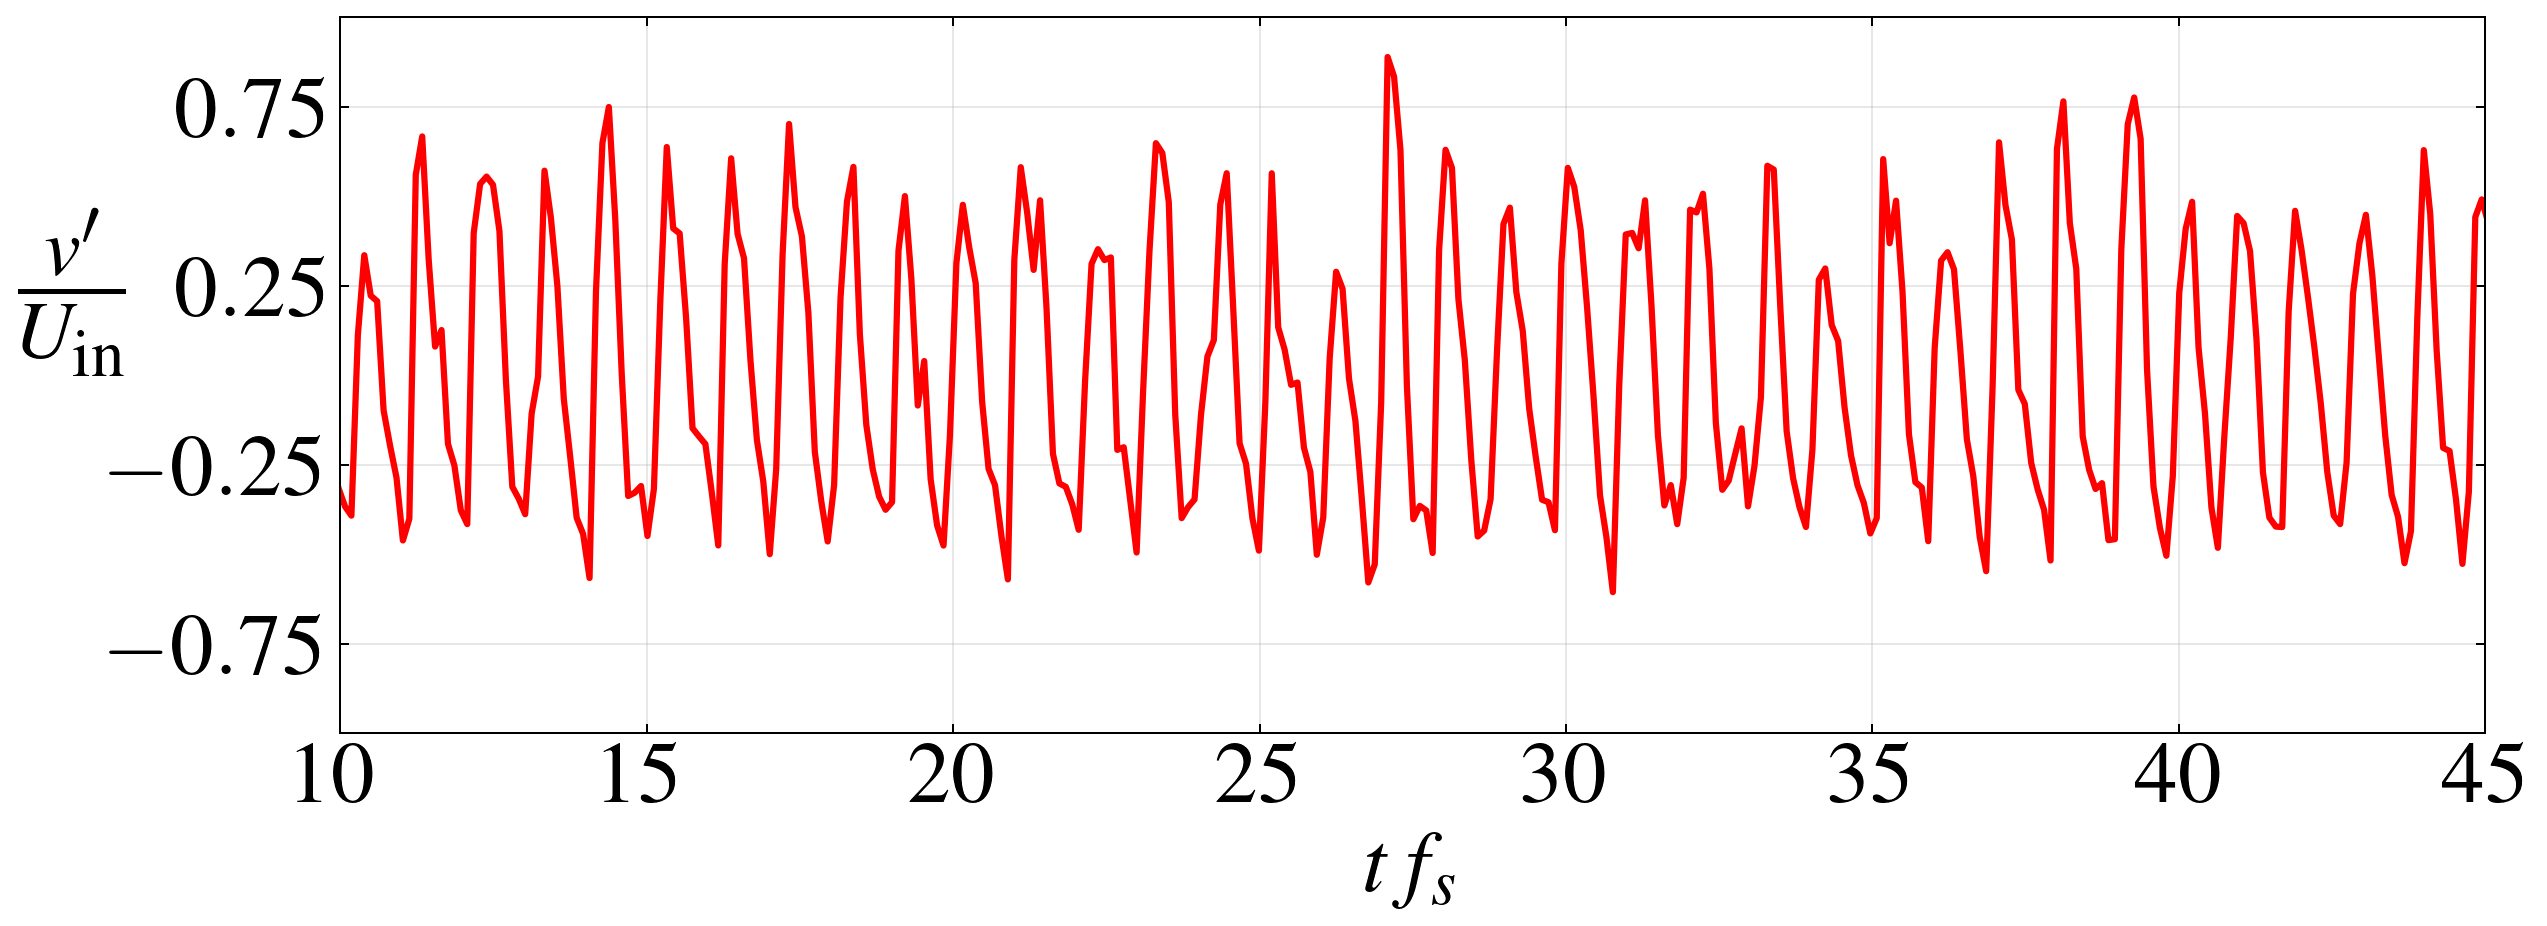

In [26]:
# ==============================================================
# Time series of transverse velocity fluctuation at (2.5D, 0.5D)
# ==============================================================

import h5py
import numpy as np
import matplotlib.pyplot as plt

master_font_size = 35
mpl.rcParams.update({
    'figure.figsize': (8.0, 2.8),
    'figure.dpi': 180,
    'savefig.dpi': 600,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'STIXGeneral', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'axes.labelsize': master_font_size,
    'axes.titlesize': master_font_size,
    'font.size': master_font_size,
    'xtick.labelsize': master_font_size,
    'ytick.labelsize': master_font_size,
    'legend.fontsize': master_font_size,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'image.cmap': 'jet',
})

# --------------------------------------------------------------
# Parameters
# --------------------------------------------------------------
D = 3.18e-3      # m
U_in = 35.0      # m/s

# Sampling interval
dt = 0.5 * D / U_in

# Target nondimensional location
x_target_nd = 2.5
y_target_nd = 0.5

# Convert to dimensional coordinates
x_target = x_target_nd * D
y_target = y_target_nd * D

# --------------------------------------------------------------
# Load transverse velocity field
# --------------------------------------------------------------
v_file = "/mnt/D/work/datasets/les_datasets/v_2d.h5"

with h5py.File(v_file, "r") as f:
    v_2d = f["/ds"][:]

v_3d = v_2d.reshape([nx, ny, nt])

print("v_3d shape:", v_3d.shape)

# --------------------------------------------------------------
# Find nearest spatial point
# --------------------------------------------------------------
dist2 = (X - x_target)**2 + (Y - y_target)**2
i, j = np.unravel_index(np.argmin(dist2), dist2.shape)

print(f"Nearest grid point:")
print(f"x/D = {X[i,j]/D:.4f}")
print(f"y/D = {Y[i,j]/D:.4f}")

# --------------------------------------------------------------
# Extract time signal
# --------------------------------------------------------------
v_signal = v_3d[i, j, :]

# Remove mean to obtain fluctuation
v_fluct = v_signal - np.mean(v_signal)

# Non-dimensionalize if desired
v_fluct_nd = v_fluct / U_in

# Time vector
n_snapshots = v_3d.shape[2]
time = np.arange(n_snapshots) * dt
time_nd = time * U_in / D  # tU/D

# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------
D = 3.18e-3       # m
U_in = 35.0       # m/s
St = 0.21

# Shedding frequency
f_s = St * U_in / D

# Normalize time by shedding period
# x-axis: t * f_s
time_fs = time_nd * St   # since time_nd = t * U_in / D

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    time_fs,
    v_fluct_nd,
    color="red",
    linewidth=2.5
)

ax.set_xlabel(r"$tf_s$")
ax.set_ylabel(
    r"$\frac{v'}{U_{\mathrm{in}}}$",
    rotation=0,
    labelpad=14,
    fontsize=master_font_size+10
)

ax.grid(True, alpha=0.3)

ax.set_xlim([10, 45])
ax.set_ylim([-1.0, 1.0])
ax.set_xticks(np.arange(10, 50, 5))
ax.set_yticks(np.arange(-0.75, 0.751, 0.5))

plt.tight_layout()
plt.show()